In [23]:
import CHM as pc
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

In [28]:
# convert from the vtk unstructured mesh file to a ugrid netcdf
df = pc.open_pvd('../chm/output/meshes/tvc.pvd')
os.remove('tvc_ugrid.nc')
pc.vtu_to_ugrid(df, 'tvc_ugrid.nc', variables=['snowdepthavg']) #, '[param] LIDAR_SWE'])



MPI ranks = 1 detected in pvd
proj4 = +proj=utm +zone=8 +datum=NAD83 +units=m +no_defs
Merging blocks...
Done
Writting mesh + variables
datetime                                   2013-04-06 13:00:00
vtu_paths    [/Users/cbm038/Documents/science/model_runs/tv...
Name: 0, dtype: object


In [25]:
# regrid the ugrid file to a structured mesh
pc.ugrid2tiff('tvc_ugrid.nc',
      dxdy=0.00001795, # in degrees
      method='bilinear')

[0] numX, numY = 2666, 970
[0] umin=-133.67943085467928 umax=-133.63155944296827 vmin=68.6797561402321 vmax=68.69718167357088 
[0]  max_index=[2666  970]
[0] Using ESMF.RegridMethod.BILINEAR regridder
[0] 20130406T130000 - snowdepthavg
[0] Done regridding to partial tiffs
[0] Merging tiffs
[0] PET0 has [['snowdepthavg' '20130406T130000']]
...10...20...30...40...50...60...70...80...90...100 - done.
0[-133.6794308578147, 1.7956270810897808e-05, 0.0, 68.67975613299096, 0.0, 1.7964482289762993e-05]
lly=68.67975613299096 ds.RasterYSize=970 yres=1.7964482289762993e-05 ==> uly 68.69718168081204
[-133.6794308578147, 1.7956270810897808e-05, 0.0, 68.69718168081204, 0.0, -1.7964482289762993e-05]
[0] Done


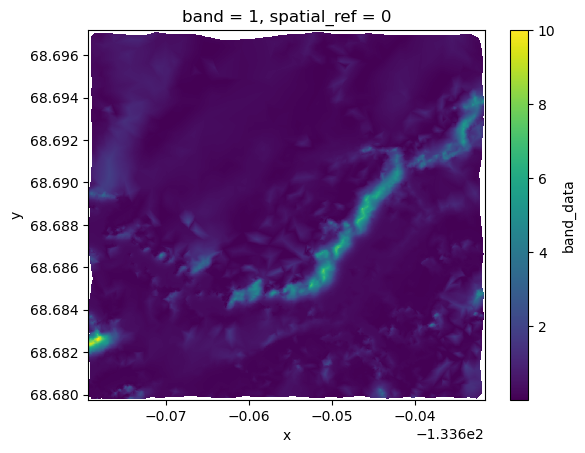

In [26]:
# 2m
ds = xr.open_mfdataset('snowdepthavg-1.795e-05x1.795e-05_20130406T130000.tiff').isel(band=0)
ds.band_data.plot()